# Tests

### Required packages:

*(loaded in the included files)*
- Random 
- Graphs 
- JuMP 
- HiGHS 
- DelimitedFiles 
- Distributions 
- Plots 
- BenchmarkProfiles 
- CSV 
- DataFrames

## ↓ Available test scprits ↓

⚠ You need to download the Kidney Exchange Problem data set (at least a great part of it) from [Preflib (Kidney Data 00036)](https://preflib.github.io/PrefLib-Jekyll/dataset/00036)

⚠ These tests are all very long. It is recommended that you run them one at a time.

In [4]:
include("tests.jl") # required package are load in this file

# init_choice_comparaison()

# sp_order_comparaison()

# methods_speed_comparaison()

# evolution_Bellmann()

# max_K_opti()


┌ Warning: To use these tests, you need to download necessary the KEP data available on Preflib (Kidney Data 00036) 
└ @ Main /Users/jeanpousset/Documents/7-Optimisation Stochastique/Projet - Transfert d'organe - Jean et Yilong/tests.jl:8


" All test scripts and algorithms are successfully loaded "

## Results visualization

In [1]:
using CSV, Plots, BenchmarkProfiles, DataFrames

### 1 - Choice of the first cycles

In [49]:
df = CSV.read("Results/init_comparaison_time.csv", DataFrame);
T, init_choices, sizes = Matrix(df[:, Not(:Instance_Size)]), names(df[!, Not(:Instance_Size)]), df.Instance_Size

# performance_profile(PlotsBackend(), T, ["moitié K=2","tous K=2","path in G_o_prime"],τ_max=2, τ_step=0.01, title="Profile de performance : choix d'initialisations", linewidth=3)
plot(xlabel="n (échelle log2)", ylabel="Temps de résolution moyens (échelle log10)", title="Impact du choix des premiers cycles", yscale=:log10, xscale=:log2, xticks=(sizes, string.(sizes)))
plot!(sizes,T[:,1], label="moitié K = 2")
plot!(sizes,T[:,2], label="tous K = 2")
plot!(sizes,T[:,3], label="1 cycle par sommet")

savefig("Figures/init_choice.svg")

"/Users/jeanpousset/Documents/7-Optimisation Stochastique/Projet - Transfert d'organe - Jean et Yilong/Figures/init_choice.svg"

### 2 - Solving order

In [48]:
df = CSV.read("Results/order_comparaison_time.csv", DataFrame);
T, order_choices, sizes = Matrix(df[:, Not(:Instance_Size)]), names(df[!, Not(:Instance_Size)]), df.Instance_Size

# performance_profile(PlotsBackend(), T, ["base","séquentiel","aléatoire"],τ_max=2, τ_step=0.01, title="Profile de performance : ordre sous-problemes", linewidth=3)
plot(xlabel="n (échelle log2)", ylabel="Temps de résolution moyens (échelle log10)", title="Impact de l'orde de résolution des SP", yscale=:log10, xscale=:log2, xticks=(sizes, string.(sizes)))
plot!(sizes,T[:,1], label="base")
plot!(sizes,T[:,2], label="séquentiel")
plot!(sizes,T[:,3], label="aléatoire")

savefig("Figures/order_choice.svg")

"/Users/jeanpousset/Documents/7-Optimisation Stochastique/Projet - Transfert d'organe - Jean et Yilong/Figures/order_choice.svg"

### 3 - Resolution methods

In [47]:
df = CSV.read("Results/method_comparaison_time.csv", DataFrame);
T, methods, sizes = Matrix(df[:, Not(:Instance_Size)]), names(df[!, Not(:Instance_Size)]), df.Instance_Size

performance_profile(PlotsBackend(), T, ["brute force","formulation compact","PLNE","Bellmann"], title="Profile de performance : méthode de résolution", linewidth=3)
savefig("Figures/pp_method.svg")

plot(xlabel="n (échelle log2)", ylabel="Temps de résolution moyens (échelle log10)", title="Méthodes de résolutions", yscale=:log10, xscale=:log2, xticks=(sizes, string.(sizes)))
plot!(sizes,T[:,1], label="brute force", linewidth=2)
plot!(sizes,T[:,2], label="fromulation compacte", linewidth=2)
plot!(sizes,T[:,3], label="PLNE", linewidth=2)
plot!(sizes,T[:,4], label="Bellmann", linewidth=2)

savefig("Figures/method_comparaison.svg")

"/Users/jeanpousset/Documents/7-Optimisation Stochastique/Projet - Transfert d'organe - Jean et Yilong/Figures/method_comparaison.svg"

### 4 - Optimality Check

In [ ]:
losses_percentages = CSV.read("Results/order_comparaison_losses.csv", DataFrame);
losses_percentages


Row,Instance_Size,base,sequence,random
,Int64,Float64,Float64,Float64
1,32,0.0,0.0,0.0
2,64,0.0,0.0,0.0
3,128,0.0,0.0,0.0
4,256,0.0,0.0,0.0
5,512,0.0,0.0,0.0
6,1024,0.0,0.0,0.0


### 5 - Limite for K

In [ ]:
df = CSV.read("Results/max_K_opti.csv", DataFrame);
obj_values, K_range, sizes = Matrix(df[:, Not(:Instance_Size)]), names(df[!, Not(:Instance_Size)]), df.Instance_Size


relativ_gains = (obj_values[:,2:end].-obj_values[:,1:end-1]) ./ obj_values[:,1:end-1]

@show obj_values
@show relativ_gains
@show sizes

plot(xlabel="n (échelle log2)", ylabel="% gain moyen (échelle log10)", title="Limite gain d'incrémentation K", size=(400,300), yscale=:log10, xscale=:log2, xticks=(sizes, string.(sizes)))
for i in eachindex(K_range)[1:end-1]
    plot!(sizes,1e-15 .+abs.(relativ_gains[:,i]), label = "K : $(K_range[i]) -> $(K_range[i+1])", linewidth=2)
end

savefig("Figures/gain_K.svg")

obj_values = [0.425 0.534375 0.553125 0.553125 0.55 0.553125; 0.4375 0.5734375 0.5875 0.5875 0.5890625 0.590625; 0.50625 0.609375 0.615625 0.615625 0.615625 0.615625; 0.571875 0.63828125 0.6390625 0.6390625 0.6390625 0.6390625; 0.587109375 0.6302734375 0.63046875 0.63046875 0.63046875 0.63046875; 0.605859375 0.63359375 0.63408203125 0.63408203125 0.63408203125 0.63408203125]
relativ_gains = [0.25735294117647073 0.03508771929824549 0.0 -0.005649717514124173 0.0056818181818180605; 0.31071428571428583 0.02452316076294274 0.0 0.002659574468085144 0.002652519893899053; 0.20370370370370375 0.01025641025641022 0.0 0.0 0.0; 0.11612021857923496 0.0012239902080782657 0.0 0.0 0.0; 0.07351962741184286 0.00030988534242337387 0.0 0.0 0.0; 0.045776918117343614 0.0007706535141800247 0.0 0.0 0.0]
sizes = [32, 64, 128, 256, 512, 1024]


"/Users/jeanpousset/Documents/7-Optimisation Stochastique/Projet - Transfert d'organe - Jean et Yilong/Figures/gain_K.svg"

### 6 - Quick partiality check

In [32]:
df = CSV.read("Results/evolution_Bellmann.csv", DataFrame);
mean_pairs = df[:,:Means]

7-element Vector{Float64}:
 0.5255557209090816
 0.49406905111727745
 0.48656855008350225
 0.4877896561084394
 0.5027796507081554
 0.5014614118174537
 0.49635819942553355

### 7 - Speed of choosen method

ex_times = [0.0064535541, 0.011570187499999999, 0.0813100877, 0.2064757877, 1.1162224, 6.569773037300001, 38.8813395793]


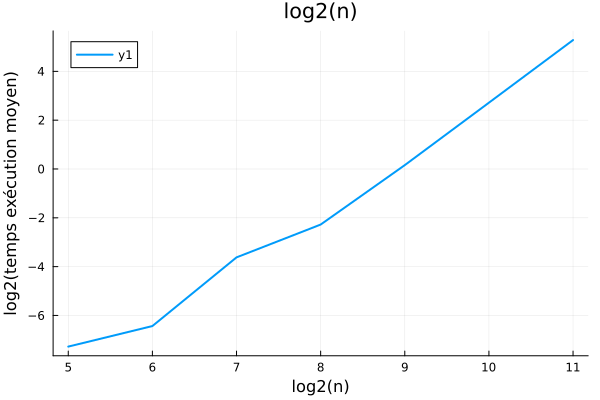

In [45]:
df = CSV.read("Results/evolution_Bellmann.csv", DataFrame);
values = Matrix(df[:, Not(:Instance_Sizes)]) 
col_names = names(df[!, Not(:Instance_Sizes)])
sizes = df.Instance_Sizes
ex_times = values[:,1]

@show ex_times

plot(xlabel="log2(n)", ylabel="log2(temps exécution moyen)", title="log2(n)")
plot!(log2.(sizes),log2.(ex_times), linewidth=2)


# savefig("Figures/gain_K.svg")